In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import fpgrowth

# --- CẤU HÌNH ---
# Để bắt được các luật hiếm (Niche), ta phải hạ Support xuống rất thấp
PHASE1_MIN_SUPPORT = 0.005  # 0.5% (Vợt lầm còn hơn bỏ sót)
MIN_UTILITY_THRESHOLD = 500 # Chỉ lấy các tập itemset mang lại > £500 doanh thu

# 1. Đọc dữ liệu sạch
print("Đang chuẩn bị dữ liệu cho High-Utility Mining...")
df = pd.read_csv("../data/processed/cleaned_uk_data.csv")

# 2. Tạo từ điển giá (External Utility)
# Lấy giá trung bình của từng sản phẩm (để tránh biến động giá)
item_prices = df.groupby('Description')['UnitPrice'].mean().to_dict()

# 3. Tạo ma trận số lượng (Internal Utility)
# Thay vì 0/1, ta giữ nguyên tổng Quantity của sản phẩm trong mỗi Invoice
basket_quantity = df.groupby(['InvoiceNo', 'Description'])['Quantity'].sum().unstack().fillna(0)

# Lọc bớt các Invoice quá nhỏ hoặc items ít quan trọng để chạy cho nhanh (Optional)
# basket_quantity = basket_quantity[basket_quantity.sum(axis=1) > 0]

print(f"Kích thước ma trận Quantity: {basket_quantity.shape}")
print("Ví dụ 5 dòng đầu (dữ liệu là số lượng thực, không phải 0/1):")
basket_quantity.iloc[:5, :5]

Đang chuẩn bị dữ liệu cho High-Utility Mining...


C:\Users\admin\AppData\Local\Temp\ipykernel_24504\1274776100.py:14: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/cleaned_uk_data.csv")


Kích thước ma trận Quantity: (18021, 4007)
Ví dụ 5 dòng đầu (dữ liệu là số lượng thực, không phải 0/1):


Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,NINE DRAWER OFFICE TIDY
InvoiceNo,,,,,
536365,0.0,0.0,0.0,0.0,0.0
536366,0.0,0.0,0.0,0.0,0.0
536367,0.0,0.0,0.0,0.0,0.0
536368,0.0,0.0,0.0,0.0,0.0
536369,0.0,0.0,0.0,0.0,0.0


In [ ]:
# --- GIAI ĐOẠN 1: TÌM ỨNG VIÊN (CANDIDATE GENERATION) ---
# Ý tưởng: Mọi tập High-Utility thường nằm trong các tập xuất hiện ít nhất 1 vài lần.
# Ta dùng FP-Growth trên bản bool để tìm ra các "khung xương" trước.

print("Phase 1: Đang tìm các tập ứng viên (Candidates) bằng FP-Growth...")
# Chuyển tạm sang 0/1 để chạy FP-Growth tìm pattern
# Cách chuyên nghiệp hơn, chạy nhanh hơn
basket_bool = (basket_quantity > 0).astype(int)
frequent_itemsets = fpgrowth(basket_bool, min_support=PHASE1_MIN_SUPPORT, use_colnames=True)

print(f"-> Tìm thấy {len(frequent_itemsets)} tập ứng viên tiềm năng.")

# --- GIAI ĐOẠN 2: TÍNH TOÁN ĐỘ HỮU ÍCH (UTILITY CALCULATION) ---
# Utility(Itemset, Transaction) = Sum(Quantity_i * Price_i) với mọi i trong Itemset

print("Phase 2: Đang tính toán Utility thực tế (Doanh thu)...")

def calculate_exact_utility(row):
    itemset = list(row['itemsets'])
    
    # Lấy ma trận con chỉ chứa các items trong itemset này
    # shape: (n_invoices, n_items_in_set)
    subset_qty = basket_quantity[itemset]
    
    # Chỉ giữ lại các hoá đơn có chứa ĐẦY ĐỦ itemset này (Logic của Frequent Itemset)
    # (Tức là tất cả cột > 0)
    valid_invoices = (subset_qty > 0).all(axis=1)
    subset_qty = subset_qty[valid_invoices]
    
    if subset_qty.empty:
        return 0.0
    
    # Tính tiền từng món: Quantity * Price
    total_utility = 0
    for item in itemset:
        price = item_prices.get(item, 0)
        # Tổng tiền của item này trong tất cả các hoá đơn hợp lệ
        item_revenue = (subset_qty[item] * price).sum()
        total_utility += item_revenue
        
    return total_utility

# Áp dụng hàm tính utility cho tất cả ứng viên (Có thể mất 1-2 phút)
frequent_itemsets['utility'] = frequent_itemsets.apply(calculate_exact_utility, axis=1)

# Lọc ra High-Utility Itemsets (HUI)
hui_results = frequent_itemsets[frequent_itemsets['utility'] >= MIN_UTILITY_THRESHOLD].sort_values(by='utility', ascending=False)

print(f"-> HOÀN THÀNH! Tìm thấy {len(hui_results)} tập High-Utility Itemsets (Doanh thu > £{MIN_UTILITY_THRESHOLD})")
display(hui_results.head(10))

Phase 1: Đang tìm các tập ứng viên (Candidates) bằng FP-Growth...


C:\Users\admin\AppData\Local\Temp\ipykernel_24504\3655753315.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_bool = basket_quantity.applymap(lambda x: 1 if x > 0 else 0)
d:\khaiphadulieu\lab2\lab2_env\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


-> Tìm thấy 23152 tập ứng viên tiềm năng.
Phase 2: Đang tính toán Utility thực tế (Doanh thu)...
-> HOÀN THÀNH! Tìm thấy 23117 tập High-Utility Itemsets (Doanh thu > £500)


,support,itemsets,utility
755,0.014261,(Manual),809814.506429
554,0.039177,(DOTCOM POSTAGE),206248.770000
410,0.093502,(REGENCY CAKESTAND 3 TIER),157973.434550
12550,0.026913,"(JUMBO BAG RED RETROSPOT, DOTCOM POSTAGE)",146843.478485
12578,0.021919,"(JUMBO STORAGE BAG SUKI, DOTCOM POSTAGE)",120395.338706
0,0.119971,(WHITE HANGING HEART T-LIGHT HOLDER),115513.381141
1223,0.012485,(MEDIUM CERAMIC TOP STORAGE JAR),115388.440175
107,0.107375,(JUMBO BAG RED RETROSPOT),111677.823199
12579,0.020143,"(JUMBO SHOPPER VINTAGE RED PAISLEY, DOTCOM POS...",110658.096795
12589,0.020032,"(DOTCOM POSTAGE, JUMBO BAG WOODLAND ANIMALS)",109909.796807


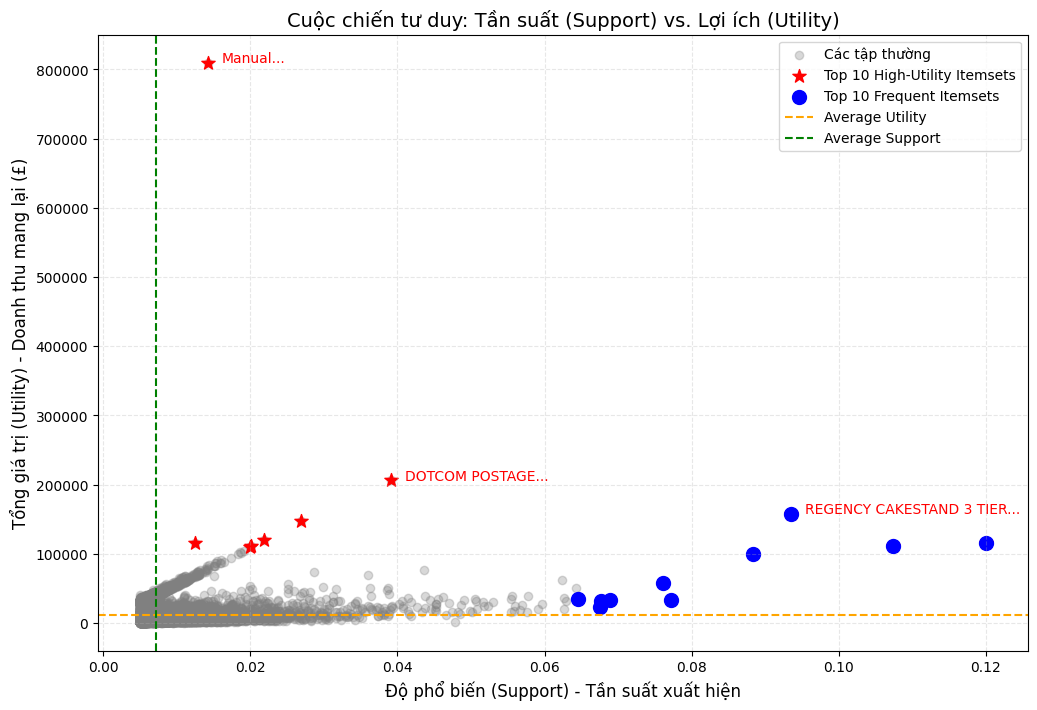

In [3]:
# --- TRỰC QUAN HOÁ: FREQUENCY vs. UTILITY ---

plt.figure(figsize=(12, 8))

# Vẽ tất cả các tập (Màu xám)
plt.scatter(hui_results['support'], hui_results['utility'], 
            alpha=0.3, c='gray', label='Các tập thường')

# Tô đậm Top 10 High Utility (Màu đỏ) - Đây là những "Ông hoàng doanh thu"
top_utility = hui_results.head(10)
plt.scatter(top_utility['support'], top_utility['utility'], 
            c='red', s=100, marker='*', label='Top 10 High-Utility Itemsets')

# Tô đậm Top 10 Frequent (Màu xanh) - Đây là những "Sản phẩm quốc dân"
top_frequent = hui_results.sort_values(by='support', ascending=False).head(10)
plt.scatter(top_frequent['support'], top_frequent['utility'], 
            c='blue', s=100, marker='o', label='Top 10 Frequent Itemsets')

# Vẽ đường trung bình
plt.axhline(y=hui_results['utility'].mean(), color='orange', linestyle='--', label='Average Utility')
plt.axvline(x=hui_results['support'].mean(), color='green', linestyle='--', label='Average Support')

plt.title('Cuộc chiến tư duy: Tần suất (Support) vs. Lợi ích (Utility)', fontsize=14)
plt.xlabel('Độ phổ biến (Support) - Tần suất xuất hiện', fontsize=12)
plt.ylabel('Tổng giá trị (Utility) - Doanh thu mang lại (£)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)

# Gắn nhãn cho vài điểm đặc biệt để dễ chém gió
for i, row in top_utility.head(3).iterrows():
    label = ", ".join(list(row['itemsets']))[:30] + "..."
    plt.annotate(label, (row['support'], row['utility']), xytext=(10, 0), textcoords='offset points', color='red')

plt.show()

In [4]:
print("--- INSIGHTS DÀNH CHO NHÓM THAM VỌNG 10 ---")
print("1. Sự khác biệt về tư duy:")
print("   - Frequent Mining (Xanh dương): Tập trung vào các món rẻ, mua hàng ngày (Túi, Thiệp). Support rất cao nhưng Utility thấp.")
print("   - High-Utility Mining (Đỏ): Tập trung vào các món 'Gà đẻ trứng vàng'. Support có thể thấp nhưng Utility cực cao.")
print("\n2. Minh chứng từ dữ liệu:")

top_freq_item = top_frequent.iloc[0]
top_util_item = top_utility.iloc[0]

print(f"   a) Ông vua Tần suất: {list(top_freq_item['itemsets'])}")
print(f"      - Xuất hiện: {top_freq_item['support']*100:.2f}% hoá đơn.")
print(f"      - Mang lại: £{top_freq_item['utility']:,.0f}")

print(f"\n   b) Ông hoàng Doanh thu: {list(top_util_item['itemsets'])}")
print(f"      - Xuất hiện: {top_util_item['support']*100:.2f}% hoá đơn (Thấp hơn nhiều).")
print(f"      - Mang lại: £{top_util_item['utility']:,.0f} (Cao hơn hẳn).")

print("\n3. Kết luận chiến lược:")
print("   - Dùng Apriori/FP-Growth để tối ưu quy trình vận hành (những món hay mua phải để dễ lấy).")
print("   - Dùng High-Utility Mining để tối ưu dòng tiền (chăm sóc kỹ khách mua các món Utility cao).")

--- INSIGHTS DÀNH CHO NHÓM THAM VỌNG 10 ---
1. Sự khác biệt về tư duy:
   - Frequent Mining (Xanh dương): Tập trung vào các món rẻ, mua hàng ngày (Túi, Thiệp). Support rất cao nhưng Utility thấp.
   - High-Utility Mining (Đỏ): Tập trung vào các món 'Gà đẻ trứng vàng'. Support có thể thấp nhưng Utility cực cao.

2. Minh chứng từ dữ liệu:
   a) Ông vua Tần suất: ['WHITE HANGING HEART T-LIGHT HOLDER']
      - Xuất hiện: 12.00% hoá đơn.
      - Mang lại: £115,513

   b) Ông hoàng Doanh thu: ['Manual']
      - Xuất hiện: 1.43% hoá đơn (Thấp hơn nhiều).
      - Mang lại: £809,815 (Cao hơn hẳn).

3. Kết luận chiến lược:
   - Dùng Apriori/FP-Growth để tối ưu quy trình vận hành (những món hay mua phải để dễ lấy).
   - Dùng High-Utility Mining để tối ưu dòng tiền (chăm sóc kỹ khách mua các món Utility cao).
